In [1]:
# ============================================================
# Cell 1: Imports & Environment Sanity Check
# ============================================================

# ---- Standard library ----
import os
import sys
import json
import time
import math
import random
from pathlib import Path
from collections import defaultdict

# ---- Numerical / scientific ----
import numpy as np
import pandas as pd

# ---- Image processing ----
import cv2
from PIL import Image

# ---- Deep learning ----
import torch
import torchvision
from torchvision.ops import box_convert

# ---- RF-DETR ----
from rfdetr import RFDETRNano

# ---- Dataset / evaluation ----
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ---- Augmentation / preprocessing ----
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---- Visualization ----
import matplotlib.pyplot as plt

# ---- Utilities ----
from tqdm import tqdm
import psutil
import yaml

# ============================================================
# Reproducibility helper
# ============================================================

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ============================================================
# Environment sanity prints
# ============================================================

print("=== Environment Check ===")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"Torchvision version : {torchvision.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(f"CPU cores           : {psutil.cpu_count(logical=True)}")
print(f"Random seed         : {SEED}")
print("=========================")

=== Environment Check ===
Python version      : 3.11.9
PyTorch version     : 2.5.1+cu121
Torchvision version : 0.20.1+cu121
CUDA available      : True
CUDA version        : 12.1
GPU                 : NVIDIA GeForce RTX 2070 SUPER
CPU cores           : 8
Random seed         : 42


In [2]:
# ============================================================
# Cell 2: Canonical Class Mapping (DroneVehicle -> Phase 3 Classes)
# SINGLE SOURCE OF TRUTH
# ============================================================

# ---- Phase 3 canonical classes ----
# These IDs are FINAL for this project and must be used everywhere:
# - COCO export
# - training
# - evaluation
# - inference
# - visualization
PHASE3_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

NUM_CLASSES = len(PHASE3_CLASSES)

# ---- Ordered canonical class names (index = class_id - 1) ----
PHASE3_CLASS_NAMES = [PHASE3_CLASSES[i] for i in range(1, NUM_CLASSES + 1)]

# ---- Inverse mapping (name -> id) ----
PHASE3_CLASS_NAME_TO_ID = {name: idx for idx, name in PHASE3_CLASSES.items()}

# ---- Original DroneVehicle classes (documented, DO NOT CHANGE) ----
# Source dataset classes:
# - car
# - truck
# - bus
# - van
# - freight car
#
# We use lowercase keys so later parsing can safely normalize XML labels.
DRONEVEHICLE_CLASSES = {
    0: "car",
    1: "truck",
    2: "bus",
    3: "van",
    4: "freight_car",
}

# ---- DroneVehicle name normalization ----
# XML labels may vary slightly in spacing/case across files or exports.
# Normalize them before mapping into the canonical Phase 3 taxonomy.
DRONEVEHICLE_NAME_NORMALIZATION = {
    "car": "car",
    "truck": "truck",
    "bus": "bus",
    "van": "van",
    "freight car": "freight_car",
    "freight_car": "freight_car",
    "freightcar": "freight_car",
}

# ---- DroneVehicle -> Phase 3 mapping ----
# Project decision:
# - car         -> Car
# - truck       -> Truck
# - bus         -> Bus
# - van         -> Car
# - freight car -> Other
DRONEVEHICLE_TO_PHASE3 = {
    "car": PHASE3_CLASS_NAME_TO_ID["Car"],
    "truck": PHASE3_CLASS_NAME_TO_ID["Truck"],
    "bus": PHASE3_CLASS_NAME_TO_ID["Bus"],
    "van": PHASE3_CLASS_NAME_TO_ID["Car"],
    "freight_car": PHASE3_CLASS_NAME_TO_ID["Other"],
}

# ---- COCO category definition (derive here, from the canonical source) ----
COCO_CATEGORIES = [
    {
        "id": class_id,
        "name": class_name,
        "supercategory": "object",
    }
    for class_id, class_name in PHASE3_CLASSES.items()
]

# ---- Metadata helpers for later cells ----
# Use these in export / training / eval / inference to avoid class-name drift.
DATASET_METADATA = {
    "dataset_name": "DroneVehicle",
    "num_classes": NUM_CLASSES,
    "class_id_to_name": PHASE3_CLASSES,
    "class_name_to_id": PHASE3_CLASS_NAME_TO_ID,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,
    "source_classes": DRONEVEHICLE_CLASSES,
    "source_to_phase3": DRONEVEHICLE_TO_PHASE3,
}

# Helper: converts model output class id -> human-readable name
def class_id_to_name(class_id: int) -> str:
    return PHASE3_CLASSES.get(int(class_id), f"unknown_{class_id}")

# Helper: normalize raw DroneVehicle XML class name
def normalize_dronevehicle_class_name(raw_name: str) -> str:
    if raw_name is None:
        raise ValueError("Raw class name is None")

    name = str(raw_name).strip().lower().replace("-", " ")
    name = " ".join(name.split())  # collapse repeated whitespace

    if name not in DRONEVEHICLE_NAME_NORMALIZATION:
        raise KeyError(f"Unknown DroneVehicle class name: {raw_name}")

    return DRONEVEHICLE_NAME_NORMALIZATION[name]

# Helper: converts raw DroneVehicle XML class name -> canonical Phase 3 id
def dronevehicle_name_to_phase3_id(raw_name: str) -> int:
    normalized_name = normalize_dronevehicle_class_name(raw_name)
    return DRONEVEHICLE_TO_PHASE3[normalized_name]

# ============================================================
# Sanity checks
# ============================================================

# Ensure Phase 3 IDs are contiguous starting at 1
assert sorted(PHASE3_CLASSES.keys()) == list(range(1, NUM_CLASSES + 1))

# Ensure ordered names align with dict
assert len(PHASE3_CLASS_NAMES) == NUM_CLASSES
for i, name in enumerate(PHASE3_CLASS_NAMES, start=1):
    assert PHASE3_CLASSES[i] == name

# Ensure COCO export categories align exactly with canonical classes
assert [c["id"] for c in COCO_CATEGORIES] == list(range(1, NUM_CLASSES + 1))
assert [c["name"] for c in COCO_CATEGORIES] == PHASE3_CLASS_NAMES

# Ensure all normalized source classes are covered by the Phase 3 mapping
normalized_source_names = set(DRONEVEHICLE_NAME_NORMALIZATION.values())
expected_source_names = set(DRONEVEHICLE_CLASSES.values())

assert normalized_source_names == expected_source_names, (
    f"Normalized DroneVehicle class set mismatch.\n"
    f"Expected: {sorted(expected_source_names)}\n"
    f"Got     : {sorted(normalized_source_names)}"
)

assert set(DRONEVEHICLE_TO_PHASE3.keys()) == expected_source_names, (
    f"DroneVehicle -> Phase 3 mapping incomplete.\n"
    f"Expected keys: {sorted(expected_source_names)}\n"
    f"Got keys     : {sorted(DRONEVEHICLE_TO_PHASE3.keys())}"
)

# Ensure mapped Phase 3 IDs are valid
assert all(
    mapped_id in PHASE3_CLASSES
    for mapped_id in DRONEVEHICLE_TO_PHASE3.values()
)

print("=== Phase 3 Class Mapping Locked ===")
print(f"Number of classes: {NUM_CLASSES}\n")

print("Phase 3 Classes:")
for k, v in PHASE3_CLASSES.items():
    print(f"  {k}: {v}")

print("\nOrdered class names:")
for i, name in enumerate(PHASE3_CLASS_NAMES, start=1):
    print(f"  {i}: {name}")

print("\nDroneVehicle Source Classes:")
for k, v in DRONEVEHICLE_CLASSES.items():
    print(f"  {k}: {v}")

print("\nDroneVehicle -> Phase 3 Mapping:")
for src_name in sorted(DRONEVEHICLE_TO_PHASE3.keys()):
    phase3_id = DRONEVEHICLE_TO_PHASE3[src_name]
    print(f"  {src_name:<12} -> Phase 3 {phase3_id} ({PHASE3_CLASSES[phase3_id]})")

print("\nCOCO Categories:")
for cat in COCO_CATEGORIES:
    print(f"  id={cat['id']} | name={cat['name']}")

print("===================================")

=== Phase 3 Class Mapping Locked ===
Number of classes: 6

Phase 3 Classes:
  1: Human
  2: Bicycle
  3: Car
  4: Truck
  5: Bus
  6: Other

Ordered class names:
  1: Human
  2: Bicycle
  3: Car
  4: Truck
  5: Bus
  6: Other

DroneVehicle Source Classes:
  0: car
  1: truck
  2: bus
  3: van
  4: freight_car

DroneVehicle -> Phase 3 Mapping:
  bus          -> Phase 3 5 (Bus)
  car          -> Phase 3 3 (Car)
  freight_car  -> Phase 3 6 (Other)
  truck        -> Phase 3 4 (Truck)
  van          -> Phase 3 3 (Car)

COCO Categories:
  id=1 | name=Human
  id=2 | name=Bicycle
  id=3 | name=Car
  id=4 | name=Truck
  id=5 | name=Bus
  id=6 | name=Other


In [4]:
# ============================================================
# Cell 3: DroneVehicle Dataset Paths & Structure Validation
# ============================================================

# ---- Project roots ----
# Assumes notebook is inside: <phase-3>/rfdetr
NOTEBOOK_DIR = Path.cwd()
RFDETR_ROOT = NOTEBOOK_DIR.parent
PHASE_ROOT = RFDETR_ROOT.parent
DRONEVEHICLE_ROOT = PHASE_ROOT / "visdrone-dataset-infrared"

# ---- Expected dataset splits ----
DRONEVEHICLE_SPLITS = {
    "train": DRONEVEHICLE_ROOT / "train",
    "val": DRONEVEHICLE_ROOT / "val",
    "test": DRONEVEHICLE_ROOT / "test",
}

# ---- Expected subfolders inside each split ----
SPLIT_DIR_LAYOUT = {
    "train": {
        "rgb_images": "trainimg",
        "ir_images": "trainimgr",
        "rgb_labels": "trainlabel",
        "ir_labels": "trainlabelr",
    },
    "val": {
        "rgb_images": "valimg",
        "ir_images": "valimgr",
        "rgb_labels": "vallabel",
        "ir_labels": "vallabelr",
    },
    "test": {
        "rgb_images": "testimg",
        "ir_images": "testimgr",
        "rgb_labels": "testlabel",
        "ir_labels": "testlabelr",
    },
}

# ---- Reusable structure summary ----
DATASET_STRUCTURE = {}

def collect_image_files(folder: Path):
    valid_suffixes = {".jpg", ".jpeg"}
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in valid_suffixes]
    )

def collect_xml_files(folder: Path):
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".xml"]
    )

print("=== DroneVehicle Dataset Structure Check ===\n")
print(f"Notebook dir      : {NOTEBOOK_DIR}")
print(f"RF-DETR root      : {RFDETR_ROOT}")
print(f"Phase root        : {PHASE_ROOT}")
print(f"DroneVehicle root : {DRONEVEHICLE_ROOT}\n")

assert DRONEVEHICLE_ROOT.exists(), f"DroneVehicle root not found: {DRONEVEHICLE_ROOT}"

for split, split_path in DRONEVEHICLE_SPLITS.items():
    print(f"[{split.upper()}]")
    print(f"Path: {split_path}")

    assert split_path.exists(), f"Missing split directory: {split_path}"

    layout = SPLIT_DIR_LAYOUT[split]

    rgb_images_dir = split_path / layout["rgb_images"]
    ir_images_dir  = split_path / layout["ir_images"]
    rgb_labels_dir = split_path / layout["rgb_labels"]
    ir_labels_dir  = split_path / layout["ir_labels"]

    # ---- Directory existence checks ----
    assert rgb_images_dir.exists(), f"Missing RGB images directory: {rgb_images_dir}"
    assert ir_images_dir.exists(),  f"Missing IR images directory: {ir_images_dir}"
    assert rgb_labels_dir.exists(), f"Missing RGB labels directory: {rgb_labels_dir}"
    assert ir_labels_dir.exists(),  f"Missing IR labels directory: {ir_labels_dir}"

    # ---- Collect files ----
    rgb_image_files = collect_image_files(rgb_images_dir)
    ir_image_files  = collect_image_files(ir_images_dir)
    rgb_xml_files   = collect_xml_files(rgb_labels_dir)
    ir_xml_files    = collect_xml_files(ir_labels_dir)

    print(f"SUCCESS: RGB images directory found ({len(rgb_image_files)} images)")
    print(f"SUCCESS: IR images directory found ({len(ir_image_files)} images)")
    print(f"SUCCESS: RGB labels directory found ({len(rgb_xml_files)} xml files)")
    print(f"SUCCESS: IR labels directory found ({len(ir_xml_files)} xml files)")

    # ---- Count checks within each modality ----
    if len(rgb_image_files) != len(rgb_xml_files):
        raise ValueError(
            f"RGB image / annotation count mismatch in split '{split}': "
            f"{len(rgb_image_files)} images vs {len(rgb_xml_files)} xml files"
        )

    if len(ir_image_files) != len(ir_xml_files):
        raise ValueError(
            f"IR image / annotation count mismatch in split '{split}': "
            f"{len(ir_image_files)} images vs {len(ir_xml_files)} xml files"
        )

    # ---- Stem consistency checks within each modality ----
    rgb_image_stems = {p.stem for p in rgb_image_files}
    rgb_xml_stems   = {p.stem for p in rgb_xml_files}

    ir_image_stems = {p.stem for p in ir_image_files}
    ir_xml_stems   = {p.stem for p in ir_xml_files}

    missing_rgb_xml = sorted(rgb_image_stems - rgb_xml_stems)
    missing_rgb_img = sorted(rgb_xml_stems - rgb_image_stems)

    missing_ir_xml = sorted(ir_image_stems - ir_xml_stems)
    missing_ir_img = sorted(ir_xml_stems - ir_image_stems)

    if missing_rgb_xml or missing_rgb_img:
        raise ValueError(
            f"RGB stem mismatch in split '{split}'.\n"
            f"RGB images without XML: {missing_rgb_xml[:5]}\n"
            f"RGB XML without images: {missing_rgb_img[:5]}"
        )

    if missing_ir_xml or missing_ir_img:
        raise ValueError(
            f"IR stem mismatch in split '{split}'.\n"
            f"IR images without XML: {missing_ir_xml[:5]}\n"
            f"IR XML without images: {missing_ir_img[:5]}"
        )

    # ---- Cross-modality consistency checks ----
    rgb_only_stems = sorted(rgb_image_stems - ir_image_stems)
    ir_only_stems  = sorted(ir_image_stems - rgb_image_stems)

    if rgb_only_stems or ir_only_stems:
        raise ValueError(
            f"RGB / IR stem mismatch in split '{split}'.\n"
            f"Present only in RGB: {rgb_only_stems[:5]}\n"
            f"Present only in IR : {ir_only_stems[:5]}"
        )

    print("SUCCESS: RGB image / annotation counts match")
    print("SUCCESS: IR image / annotation counts match")
    print("SUCCESS: RGB image / annotation filename stems match")
    print("SUCCESS: IR image / annotation filename stems match")
    print("SUCCESS: RGB / IR filename stems match")

    DATASET_STRUCTURE[split] = {
        "split_path": split_path,
        "rgb_images_dir": rgb_images_dir,
        "ir_images_dir": ir_images_dir,
        "rgb_labels_dir": rgb_labels_dir,
        "ir_labels_dir": ir_labels_dir,
        "num_rgb_images": len(rgb_image_files),
        "num_ir_images": len(ir_image_files),
        "num_rgb_annotations": len(rgb_xml_files),
        "num_ir_annotations": len(ir_xml_files),
        "paired_stems": sorted(rgb_image_stems),
    }

    print()

print("=== Structure Check Complete ===")

=== DroneVehicle Dataset Structure Check ===

Notebook dir      : E:\projects\object-identification-uav-camera\phase-3\rfdetr\training
RF-DETR root      : E:\projects\object-identification-uav-camera\phase-3\rfdetr
Phase root        : E:\projects\object-identification-uav-camera\phase-3
DroneVehicle root : E:\projects\object-identification-uav-camera\phase-3\visdrone-dataset-infrared

[TRAIN]
Path: E:\projects\object-identification-uav-camera\phase-3\visdrone-dataset-infrared\train
SUCCESS: RGB images directory found (17990 images)
SUCCESS: IR images directory found (17990 images)
SUCCESS: RGB labels directory found (17990 xml files)
SUCCESS: IR labels directory found (17990 xml files)
SUCCESS: RGB image / annotation counts match
SUCCESS: IR image / annotation counts match
SUCCESS: RGB image / annotation filename stems match
SUCCESS: IR image / annotation filename stems match
SUCCESS: RGB / IR filename stems match

[VAL]
Path: E:\projects\object-identification-uav-camera\phase-3\visdro

Inspecting split     : train
Sample stem          : 03649
RGB image            : 03649.jpg
IR image             : 03649.jpg
RGB annotation       : 03649.xml
IR annotation        : 03649.xml
Requested modality   : both

=== Parsed RGB Annotation Metadata ===
filename: DJI_0332
size    : 840 x 712 x 3
objects : 6
skipped : 2

=== Parsed IR Annotation Metadata ===
filename: DJI_0331_R
size    : 840 x 712 x 1
objects : 6
skipped : 2

RGB skip reasons:
  unknown_class_name: 2

IR skip reasons:
  unknown_class_name: 2

=== Object Inspection (RGB XML) ===
Obj 00: raw='bus', normalized='bus', phase3=5 (Bus), polygon=[(408, 111), (430, 111), (427, 156), (407, 156)], bbox_xywh=[407, 111, 23, 45], truncated=0, difficult=0
Obj 01: raw='car', normalized='car', phase3=3 (Car), polygon=[(447, 105), (462, 104), (462, 128), (447, 127)], bbox_xywh=[447, 104, 15, 24], truncated=0, difficult=0
Obj 02: raw='car', normalized='car', phase3=3 (Car), polygon=[(444, 197), (459, 196), (460, 220), (444, 221)], bb

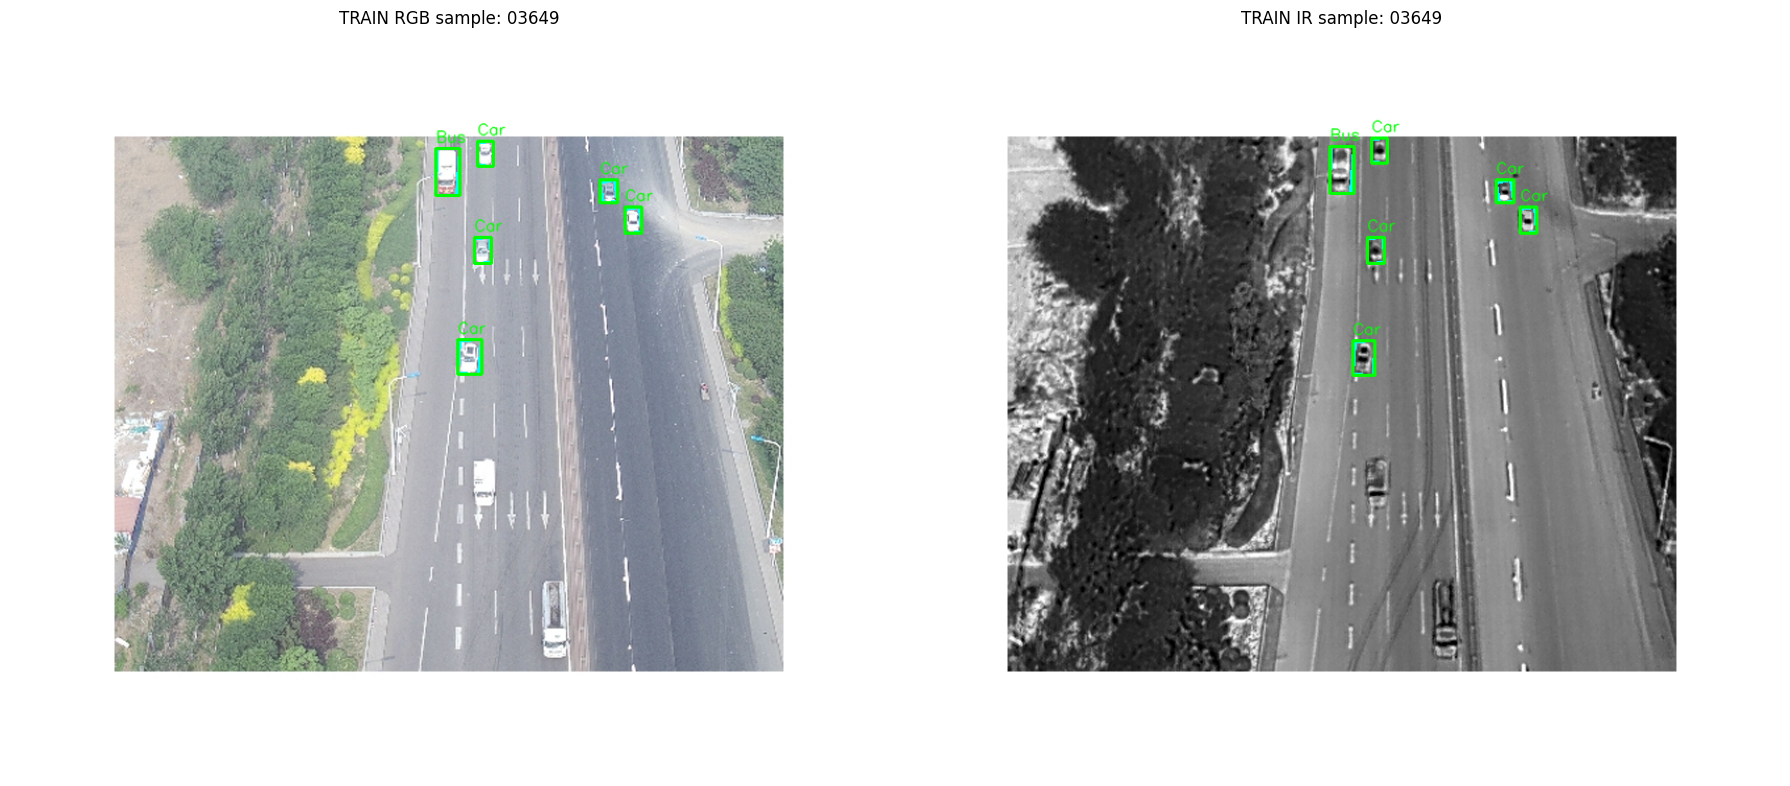

In [5]:
# ============================================================
# Cell 4: Inspect One DroneVehicle Annotation Pair + Visualize Boxes
# Robust XML parsing + class-remap sanity check + polygon->bbox conversion
# ============================================================

import xml.etree.ElementTree as ET

INSPECT_SPLIT = "train"

# Optional: set to a specific stem like "00001"
# If None, a reproducible random paired sample is used.
INSPECT_STEM = None

# Optional modality choices for inspection:
# - "rgb"
# - "ir"
# - "both"
INSPECT_MODALITY = "both"

assert INSPECT_SPLIT in DATASET_STRUCTURE, f"Unknown split: {INSPECT_SPLIT}"

rgb_images_dir = DATASET_STRUCTURE[INSPECT_SPLIT]["rgb_images_dir"]
ir_images_dir  = DATASET_STRUCTURE[INSPECT_SPLIT]["ir_images_dir"]
rgb_labels_dir = DATASET_STRUCTURE[INSPECT_SPLIT]["rgb_labels_dir"]
ir_labels_dir  = DATASET_STRUCTURE[INSPECT_SPLIT]["ir_labels_dir"]

paired_stems = DATASET_STRUCTURE[INSPECT_SPLIT]["paired_stems"]
assert len(paired_stems) > 0, f"No paired stems found for split: {INSPECT_SPLIT}"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def resolve_image_path(images_dir: Path, stem: str) -> Path:
    candidates = [
        images_dir / f"{stem}.jpg",
        images_dir / f"{stem}.JPG",
        images_dir / f"{stem}.jpeg",
        images_dir / f"{stem}.JPEG",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No image found for stem '{stem}' in {images_dir}")

def parse_dronevehicle_xml(xml_path: Path):
    """
    Parse one DroneVehicle XML file.

    Returns:
        {
            "width": int,
            "height": int,
            "depth": int or None,
            "filename": str or None,
            "objects": [
                {
                    "raw_name": str,
                    "normalized_name": str,
                    "phase3_id": int,
                    "phase3_name": str,
                    "polygon": [(x1,y1), (x2,y2), (x3,y3), (x4,y4)],
                    "bbox_xyxy": [x_min, y_min, x_max, y_max],
                    "bbox_xywh": [x, y, w, h],
                    "truncated": int or None,
                    "difficult": int or None,
                },
                ...
            ]
        }
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size_node = root.find("size")
    assert size_node is not None, f"Missing <size> in XML: {xml_path}"

    width = int(size_node.findtext("width"))
    height = int(size_node.findtext("height"))
    depth_text = size_node.findtext("depth")
    depth = int(depth_text) if depth_text is not None else None

    filename = root.findtext("filename")

    parsed_objects = []
    skip_reasons = defaultdict(int)

    for obj_idx, obj in enumerate(root.findall("object")):
        raw_name = obj.findtext("name")
        if raw_name is None:
            skip_reasons["missing_name"] += 1
            continue

        try:
            normalized_name = normalize_dronevehicle_class_name(raw_name)
            phase3_id = dronevehicle_name_to_phase3_id(raw_name)
            phase3_name = PHASE3_CLASSES[phase3_id]
        except Exception:
            skip_reasons["unknown_class_name"] += 1
            continue

        polygon = obj.find("polygon")
        if polygon is None:
            skip_reasons["missing_polygon"] += 1
            continue

        try:
            x1 = int(float(polygon.findtext("x1")))
            y1 = int(float(polygon.findtext("y1")))
            x2 = int(float(polygon.findtext("x2")))
            y2 = int(float(polygon.findtext("y2")))
            x3 = int(float(polygon.findtext("x3")))
            y3 = int(float(polygon.findtext("y3")))
            x4 = int(float(polygon.findtext("x4")))
            y4 = int(float(polygon.findtext("y4")))
        except Exception:
            skip_reasons["invalid_polygon_coordinates"] += 1
            continue

        pts = [(x1, y1), (x2, y2), (x3, y3), (x4, y4)]

        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]

        # Convert oriented polygon -> enclosing axis-aligned rectangle
        x_min = max(0, min(xs))
        y_min = max(0, min(ys))
        x_max = min(width - 1, max(xs))
        y_max = min(height - 1, max(ys))

        if x_max <= x_min or y_max <= y_min:
            skip_reasons["invalid_bbox_after_polygon_conversion"] += 1
            continue

        bbox_w = x_max - x_min
        bbox_h = y_max - y_min

        if bbox_w <= 0 or bbox_h <= 0:
            skip_reasons["non_positive_bbox"] += 1
            continue

        truncated_text = obj.findtext("truncated")
        difficult_text = obj.findtext("difficult")

        parsed_objects.append({
            "raw_name": raw_name,
            "normalized_name": normalized_name,
            "phase3_id": phase3_id,
            "phase3_name": phase3_name,
            "polygon": pts,
            "bbox_xyxy": [x_min, y_min, x_max, y_max],
            "bbox_xywh": [x_min, y_min, bbox_w, bbox_h],
            "truncated": int(truncated_text) if truncated_text is not None else None,
            "difficult": int(difficult_text) if difficult_text is not None else None,
        })

    return {
        "width": width,
        "height": height,
        "depth": depth,
        "filename": filename,
        "objects": parsed_objects,
        "skip_reasons": dict(skip_reasons),
    }

def draw_objects_on_image(img_bgr, parsed_ann, draw_polygon=True, draw_bbox=True):
    img_vis = img_bgr.copy()

    for obj in parsed_ann["objects"]:
        cls_name = obj["phase3_name"]
        pts = obj["polygon"]
        x_min, y_min, x_max, y_max = obj["bbox_xyxy"]

        if draw_polygon:
            poly = np.array(pts, dtype=np.int32).reshape((-1, 1, 2))
            cv2.polylines(img_vis, [poly], isClosed=True, color=(255, 255, 0), thickness=2)

        if draw_bbox:
            cv2.rectangle(
                img_vis,
                (x_min, y_min),
                (x_max, y_max),
                (0, 255, 0),
                2
            )

        cv2.putText(
            img_vis,
            cls_name,
            (x_min, max(15, y_min - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA
        )

    return img_vis

# ------------------------------------------------------------
# Pick sample stem
# ------------------------------------------------------------
if INSPECT_STEM is not None:
    sample_stem = INSPECT_STEM
    assert sample_stem in paired_stems, f"Stem '{sample_stem}' not found in split '{INSPECT_SPLIT}'"
else:
    rng = random.Random(SEED)
    sample_stem = rng.choice(paired_stems)

rgb_xml_path = rgb_labels_dir / f"{sample_stem}.xml"
ir_xml_path  = ir_labels_dir / f"{sample_stem}.xml"
rgb_img_path = resolve_image_path(rgb_images_dir, sample_stem)
ir_img_path  = resolve_image_path(ir_images_dir, sample_stem)

assert rgb_xml_path.exists(), f"RGB XML not found: {rgb_xml_path}"
assert ir_xml_path.exists(), f"IR XML not found: {ir_xml_path}"

print(f"Inspecting split     : {INSPECT_SPLIT}")
print(f"Sample stem          : {sample_stem}")
print(f"RGB image            : {rgb_img_path.name}")
print(f"IR image             : {ir_img_path.name}")
print(f"RGB annotation       : {rgb_xml_path.name}")
print(f"IR annotation        : {ir_xml_path.name}")
print(f"Requested modality   : {INSPECT_MODALITY}")

# ------------------------------------------------------------
# Parse annotations
# ------------------------------------------------------------
rgb_ann = parse_dronevehicle_xml(rgb_xml_path)
ir_ann  = parse_dronevehicle_xml(ir_xml_path)

print("\n=== Parsed RGB Annotation Metadata ===")
print(f"filename: {rgb_ann['filename']}")
print(f"size    : {rgb_ann['width']} x {rgb_ann['height']} x {rgb_ann['depth']}")
print(f"objects : {len(rgb_ann['objects'])}")
print(f"skipped : {sum(rgb_ann['skip_reasons'].values())}")

print("\n=== Parsed IR Annotation Metadata ===")
print(f"filename: {ir_ann['filename']}")
print(f"size    : {ir_ann['width']} x {ir_ann['height']} x {ir_ann['depth']}")
print(f"objects : {len(ir_ann['objects'])}")
print(f"skipped : {sum(ir_ann['skip_reasons'].values())}")

if rgb_ann["skip_reasons"]:
    print("\nRGB skip reasons:")
    for reason, count in sorted(rgb_ann["skip_reasons"].items()):
        print(f"  {reason}: {count}")

if ir_ann["skip_reasons"]:
    print("\nIR skip reasons:")
    for reason, count in sorted(ir_ann["skip_reasons"].items()):
        print(f"  {reason}: {count}")

# ------------------------------------------------------------
# Print object-by-object sanity info from RGB annotation
# (IR is expected to match closely, so RGB is enough for verbose print)
# ------------------------------------------------------------
phase3_counts = defaultdict(int)

print("\n=== Object Inspection (RGB XML) ===")
for idx, obj in enumerate(rgb_ann["objects"]):
    phase3_counts[obj["phase3_name"]] += 1
    print(
        f"Obj {idx:02d}: "
        f"raw='{obj['raw_name']}', "
        f"normalized='{obj['normalized_name']}', "
        f"phase3={obj['phase3_id']} ({obj['phase3_name']}), "
        f"polygon={obj['polygon']}, "
        f"bbox_xywh={obj['bbox_xywh']}, "
        f"truncated={obj['truncated']}, "
        f"difficult={obj['difficult']}"
    )

print("\n=== Inspection Summary ===")
print(f"Drawn objects: {len(rgb_ann['objects'])}")

print("\nPhase 3 class counts in this sample:")
for cls_name in PHASE3_CLASS_NAMES:
    print(f"  {cls_name:<8}: {phase3_counts.get(cls_name, 0)}")

# ------------------------------------------------------------
# Load images
# ------------------------------------------------------------
rgb_img = cv2.imread(str(rgb_img_path), cv2.IMREAD_COLOR)
ir_img  = cv2.imread(str(ir_img_path), cv2.IMREAD_COLOR)

assert rgb_img is not None, f"Failed to load RGB image: {rgb_img_path}"
assert ir_img is not None, f"Failed to load IR image: {ir_img_path}"

rgb_vis = draw_objects_on_image(rgb_img, rgb_ann, draw_polygon=True, draw_bbox=True)
ir_vis  = draw_objects_on_image(ir_img, ir_ann, draw_polygon=True, draw_bbox=True)

rgb_vis = cv2.cvtColor(rgb_vis, cv2.COLOR_BGR2RGB)
ir_vis  = cv2.cvtColor(ir_vis, cv2.COLOR_BGR2RGB)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
if INSPECT_MODALITY == "rgb":
    plt.figure(figsize=(12, 8))
    plt.imshow(rgb_vis)
    plt.axis("off")
    plt.title(f"{INSPECT_SPLIT.upper()} RGB sample: {sample_stem}")
    plt.show()

elif INSPECT_MODALITY == "ir":
    plt.figure(figsize=(12, 8))
    plt.imshow(ir_vis)
    plt.axis("off")
    plt.title(f"{INSPECT_SPLIT.upper()} IR sample: {sample_stem}")
    plt.show()

elif INSPECT_MODALITY == "both":
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    axes[0].imshow(rgb_vis)
    axes[0].axis("off")
    axes[0].set_title(f"{INSPECT_SPLIT.upper()} RGB sample: {sample_stem}")

    axes[1].imshow(ir_vis)
    axes[1].axis("off")
    axes[1].set_title(f"{INSPECT_SPLIT.upper()} IR sample: {sample_stem}")

    plt.tight_layout()
    plt.show()

else:
    raise ValueError(f"Unsupported INSPECT_MODALITY: {INSPECT_MODALITY}")

In [6]:
# ============================================================
# Cell 5: COCO Schema View + Phase 3 Training Contract
# ============================================================

print("=== COCO Categories (Canonical) ===")
for cat in COCO_CATEGORIES:
    print(f"  id={cat['id']} | name={cat['name']}")
print("===================================\n")

# ---- Target input resolution for RF-DETR Nano ----
# Keep 512 from enhanced training for better small-object performance.
TARGET_IMAGE_SIZE = 512

print(f"Target model input resolution: {TARGET_IMAGE_SIZE} x {TARGET_IMAGE_SIZE}\n")

# ---- DroneVehicle image geometry ----
# Dataset description:
# - downloaded image size is 840 x 712
# - a white border of 100 px exists on all four sides
# - training can remove the border and use the inner content region
DRONEVEHICLE_ORIGINAL_IMAGE_SIZE = {
    "width": 840,
    "height": 712,
}

DRONEVEHICLE_BORDER_POLICY = {
    "remove_white_border": True,
    "border_pixels": {
        "left": 100,
        "right": 100,
        "top": 100,
        "bottom": 100,
    },
    "expected_cropped_size": {
        "width": 840 - 100 - 100,   # 640
        "height": 712 - 100 - 100,  # 512
    },
    "apply_during_coco_export": True,
    "apply_consistently_to_rgb_and_ir": True,
    "adjust_annotation_coordinates_after_crop": True,
}

print("=== DroneVehicle Border Policy ===")
for k, v in DRONEVEHICLE_BORDER_POLICY.items():
    print(f"{k}: {v}")
print("==================================\n")

# ---- Preprocessing policy (PHASE 3) ----
PREPROCESSING_POLICY = {
    "image": {
        "target_size": TARGET_IMAGE_SIZE,
        "resize_enabled": True,
        "resize_method": "resize_longest_side_then_pad",
        "preserve_aspect_ratio": True,
        "pad_value": 0,
        "input_expected_after_border_crop": {
            "width": DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["width"],
            "height": DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["height"],
        },
    },
    "annotations": {
        "source_format": "xml_polygon",
        "source_box_type": "oriented_box_polygon",
        "convert_to_axis_aligned_coco_bbox": True,
        "polygon_to_bbox_method": "minmax_enclosing_rectangle",
        "crop_boxes_with_image": True,
        "clip_boxes_to_image": True,
        "filter_non_positive_boxes": True,
        "min_box_area_px_after_resize": 4,
    },
    "normalization": {
        "enabled": True,
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225],
    },
    "training_phase3": {
        "continuation_training": True,
        "initialize_from_previous_checkpoint": True,
        "source_checkpoint_family": "enhanced-training",
        "small_object_focus": True,
        "aggressive_random_crop": False,
        "heavy_downscale_augmentation": False,
        "paired_modal_dataset": True,
        "planned_training_usage": "treat_rgb_and_ir_as_independent_detection_samples_after_conversion",
        "notes": (
            "Phase 3 continues training from the enhanced RF-DETR Nano checkpoint "
            "using DroneVehicle RGB/infrared data converted into COCO-style "
            "axis-aligned detection annotations."
        ),
    }
}

# ---- Experiment metadata ----
EXPERIMENT_METADATA = {
    "experiment_name": "phase-3-dronevehicle-finetune",
    "based_on": "enhanced-training",
    "dataset_name": "DroneVehicle",
    "dataset_modalities": ["rgb", "infrared"],
    "primary_change_1": "switch from VisDrone-derived dataset to DroneVehicle",
    "primary_change_2": "continue training from enhanced RF-DETR Nano checkpoint",
    "primary_change_3": "convert XML oriented polygons into axis-aligned COCO boxes",
    "primary_change_4": "remove 100-pixel white border before export/training",
    "expected_effect": (
        "improved adaptation to vehicle-focused RGB/infrared aerial imagery, "
        "especially in low-light infrared conditions"
    ),
}

# ---- Compact metadata bundle for later cells ----
TRAINING_CONTRACT = {
    "num_classes": NUM_CLASSES,
    "class_names": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "original_image_size": DRONEVEHICLE_ORIGINAL_IMAGE_SIZE,
    "border_policy": DRONEVEHICLE_BORDER_POLICY,
    "preprocessing_policy": PREPROCESSING_POLICY,
    "experiment_metadata": EXPERIMENT_METADATA,
}

print("=== Preprocessing Policy ===")
for section, cfg in PREPROCESSING_POLICY.items():
    print(f"{section}: {cfg}")
print("============================\n")

print("=== Experiment Metadata ===")
for k, v in EXPERIMENT_METADATA.items():
    print(f"{k}: {v}")
print("===========================\n")

print("=== Training Contract Summary ===")
print(f"num_classes       : {TRAINING_CONTRACT['num_classes']}")
print(f"class_names       : {TRAINING_CONTRACT['class_names']}")
print(f"target_image_size : {TRAINING_CONTRACT['target_image_size']}")
print(f"dataset_name      : {TRAINING_CONTRACT['experiment_metadata']['dataset_name']}")
print(f"experiment_name   : {TRAINING_CONTRACT['experiment_metadata']['experiment_name']}")
print("=================================")

=== COCO Categories (Canonical) ===
  id=1 | name=Human
  id=2 | name=Bicycle
  id=3 | name=Car
  id=4 | name=Truck
  id=5 | name=Bus
  id=6 | name=Other

Target model input resolution: 512 x 512

=== DroneVehicle Border Policy ===
remove_white_border: True
border_pixels: {'left': 100, 'right': 100, 'top': 100, 'bottom': 100}
expected_cropped_size: {'width': 640, 'height': 512}
apply_during_coco_export: True
apply_consistently_to_rgb_and_ir: True
adjust_annotation_coordinates_after_crop: True

=== Preprocessing Policy ===
image: {'target_size': 512, 'resize_enabled': True, 'resize_method': 'resize_longest_side_then_pad', 'preserve_aspect_ratio': True, 'pad_value': 0, 'input_expected_after_border_crop': {'width': 640, 'height': 512}}
annotations: {'source_format': 'xml_polygon', 'source_box_type': 'oriented_box_polygon', 'convert_to_axis_aligned_coco_bbox': True, 'polygon_to_bbox_method': 'minmax_enclosing_rectangle', 'crop_boxes_with_image': True, 'clip_boxes_to_image': True, 'filter_n

In [13]:
# ============================================================
# Cell 6: Create or Reuse DroneVehicle -> COCO Exports
# RGB and IR are exported as independent COCO samples
# ============================================================

import xml.etree.ElementTree as ET

COCO_OUTPUT_DIR = RFDETR_ROOT / "coco_annotations_dronevehicle"
COCO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COCO_EXPORT_SUMMARY = {}

COCO_TRAIN_JSON = COCO_OUTPUT_DIR / "dronevehicle_train_coco.json"
COCO_VAL_JSON = COCO_OUTPUT_DIR / "dronevehicle_val_coco.json"
COCO_TEST_JSON = COCO_OUTPUT_DIR / "dronevehicle_test_coco.json"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def get_border_crop_params():
    border_cfg = DRONEVEHICLE_BORDER_POLICY["border_pixels"]
    left = int(border_cfg["left"])
    right = int(border_cfg["right"])
    top = int(border_cfg["top"])
    bottom = int(border_cfg["bottom"])
    return left, right, top, bottom


def compute_cropped_dimensions(width: int, height: int):
    if not DRONEVEHICLE_BORDER_POLICY["remove_white_border"]:
        return width, height

    left, right, top, bottom = get_border_crop_params()
    cropped_w = width - left - right
    cropped_h = height - top - bottom

    if cropped_w <= 0 or cropped_h <= 0:
        raise ValueError(
            f"Invalid cropped size after border removal: "
            f"orig=({width}, {height}), crop=({cropped_w}, {cropped_h})"
        )

    return cropped_w, cropped_h


def parse_dronevehicle_xml_for_coco(xml_path: Path):
    """
    Parse one DroneVehicle XML into raw object polygons + metadata.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size_node = root.find("size")
    assert size_node is not None, f"Missing <size> in XML: {xml_path}"

    width = int(size_node.findtext("width"))
    height = int(size_node.findtext("height"))
    depth_text = size_node.findtext("depth")
    depth = int(depth_text) if depth_text is not None else None
    filename = root.findtext("filename")

    objects = []
    skip_reasons = defaultdict(int)

    for obj in root.findall("object"):
        raw_name = obj.findtext("name")
        if raw_name is None:
            skip_reasons["missing_name"] += 1
            continue

        try:
            normalized_name = normalize_dronevehicle_class_name(raw_name)
            phase3_id = dronevehicle_name_to_phase3_id(raw_name)
            phase3_name = PHASE3_CLASSES[phase3_id]
        except Exception:
            skip_reasons["unknown_class_name"] += 1
            continue

        polygon = obj.find("polygon")
        if polygon is None:
            skip_reasons["missing_polygon"] += 1
            continue

        try:
            pts = [
                (float(polygon.findtext("x1")), float(polygon.findtext("y1"))),
                (float(polygon.findtext("x2")), float(polygon.findtext("y2"))),
                (float(polygon.findtext("x3")), float(polygon.findtext("y3"))),
                (float(polygon.findtext("x4")), float(polygon.findtext("y4"))),
            ]
        except Exception:
            skip_reasons["invalid_polygon_coordinates"] += 1
            continue

        truncated_text = obj.findtext("truncated")
        difficult_text = obj.findtext("difficult")

        objects.append({
            "raw_name": raw_name,
            "normalized_name": normalized_name,
            "phase3_id": phase3_id,
            "phase3_name": phase3_name,
            "polygon": pts,
            "truncated": int(truncated_text) if truncated_text is not None else 0,
            "difficult": int(difficult_text) if difficult_text is not None else 0,
        })

    return {
        "width": width,
        "height": height,
        "depth": depth,
        "filename": filename,
        "objects": objects,
        "skip_reasons": dict(skip_reasons),
    }


def convert_polygon_to_coco_bbox(
    polygon_pts,
    orig_width: int,
    orig_height: int,
    remove_border: bool = True,
):
    """
    Convert 4-point polygon -> cropped/clipped axis-aligned COCO bbox [x, y, w, h].
    """
    xs = [p[0] for p in polygon_pts]
    ys = [p[1] for p in polygon_pts]

    if remove_border:
        left, right, top, bottom = get_border_crop_params()
        cropped_width = orig_width - left - right
        cropped_height = orig_height - top - bottom

        xs = [x - left for x in xs]
        ys = [y - top for y in ys]

        img_w = cropped_width
        img_h = cropped_height
    else:
        img_w = orig_width
        img_h = orig_height

    x_min = min(xs)
    y_min = min(ys)
    x_max = max(xs)
    y_max = max(ys)

    x_min = max(0.0, min(x_min, img_w))
    y_min = max(0.0, min(y_min, img_h))
    x_max = max(0.0, min(x_max, img_w))
    y_max = max(0.0, min(y_max, img_h))

    bbox_w = x_max - x_min
    bbox_h = y_max - y_min

    if bbox_w <= 0 or bbox_h <= 0:
        return None

    return [x_min, y_min, bbox_w, bbox_h]


def resolve_image_path(images_dir: Path, stem: str) -> Path:
    candidates = [
        images_dir / f"{stem}.jpg",
        images_dir / f"{stem}.JPG",
        images_dir / f"{stem}.jpeg",
        images_dir / f"{stem}.JPEG",
    ]
    for p in candidates:
        if p.exists():
            return p

    raise FileNotFoundError(f"No image found for stem '{stem}' in {images_dir}")


def load_json(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)


def inspect_coco_export(json_path: Path, split_name: str):
    coco_json = load_json(json_path)

    categories = sorted(coco_json["categories"], key=lambda c: c["id"])
    cat_ids = [c["id"] for c in categories]
    cat_names = [c["name"] for c in categories]

    assert cat_ids == list(range(1, NUM_CLASSES + 1)), (
        f"Category ID mismatch in {json_path.name}: {cat_ids}"
    )
    assert cat_names == PHASE3_CLASS_NAMES, (
        f"Category name mismatch in {json_path.name}.\n"
        f"Expected: {PHASE3_CLASS_NAMES}\n"
        f"Got     : {cat_names}"
    )

    images_total = len(coco_json["images"])
    annotations_total = len(coco_json["annotations"])

    assert images_total > 0, f"{json_path.name} has zero images"
    assert annotations_total > 0, f"{json_path.name} has zero annotations"

    modality_counts = defaultdict(int)
    phase3_class_counts = defaultdict(int)

    for img in coco_json["images"]:
        modality = img.get("modality")
        if modality is not None:
            modality_counts[modality] += 1

    for ann in coco_json["annotations"]:
        cat_id = ann["category_id"]
        assert cat_id in PHASE3_CLASSES, f"Invalid category_id={cat_id} in {json_path.name}"

        x, y, w, h = ann["bbox"]
        assert w > 0 and h > 0, f"Non-positive bbox found in {json_path.name}: {ann['bbox']}"

        phase3_class_counts[PHASE3_CLASSES[cat_id]] += 1

    summary = {
        "split": split_name,
        "images_total": images_total,
        "annotations_total": annotations_total,
        "rgb_images_total": modality_counts.get("rgb", 0),
        "ir_images_total": modality_counts.get("ir", 0),
        "phase3_class_counts": dict(phase3_class_counts),
        "output_json_path": str(json_path),
    }
    return summary


def is_coco_export_ready(json_path: Path, split_name: str):
    if not json_path.exists():
        return False

    try:
        _ = inspect_coco_export(json_path, split_name)
        return True
    except Exception as e:
        print(f"[WARN] Existing COCO export invalid for split '{split_name}': {e}")
        return False


# ------------------------------------------------------------
# Main conversion
# ------------------------------------------------------------
def convert_dronevehicle_split_to_coco(split_name, output_json_path):
    """
    Convert one DroneVehicle split into COCO format.

    Each paired stem produces:
    - one RGB COCO image entry
    - one IR COCO image entry
    """
    assert split_name in DATASET_STRUCTURE, f"Unknown split: {split_name}"

    split_info = DATASET_STRUCTURE[split_name]
    rgb_images_dir = split_info["rgb_images_dir"]
    ir_images_dir = split_info["ir_images_dir"]
    rgb_labels_dir = split_info["rgb_labels_dir"]
    ir_labels_dir = split_info["ir_labels_dir"]
    paired_stems = split_info["paired_stems"]

    coco = {
        "info": {
            "description": (
                f"DroneVehicle converted to COCO using canonical Phase 3 taxonomy "
                f"({split_name}); RGB and IR exported as independent samples"
            ),
            "version": "1.0",
            "split": split_name,
            "dataset_name": "DroneVehicle",
            "num_classes": NUM_CLASSES,
            "class_names": PHASE3_CLASS_NAMES,
            "border_removed": DRONEVEHICLE_BORDER_POLICY["remove_white_border"],
            "modalities_exported": ["rgb", "ir"],
        },
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": COCO_CATEGORIES,
    }

    stats = {
        "split": split_name,
        "paired_stems_total": len(paired_stems),
        "images_total": 0,
        "annotations_total": 0,
        "rgb_images_total": 0,
        "ir_images_total": 0,
        "rgb_annotations_total": 0,
        "ir_annotations_total": 0,
        "skip_reasons": defaultdict(int),
        "phase3_class_counts": defaultdict(int),
    }

    image_id = 1
    annotation_id = 1

    print(f"\n=== Converting split: {split_name} ===")
    print(f"Paired stems found : {len(paired_stems)}")
    print(f"Output JSON        : {output_json_path}")
    print(f"Border removal     : {DRONEVEHICLE_BORDER_POLICY['remove_white_border']}")

    for stem in tqdm(paired_stems, desc=f"Converting {split_name}"):
        sample_defs = [
            {"modality": "rgb", "images_dir": rgb_images_dir, "labels_dir": rgb_labels_dir},
            {"modality": "ir", "images_dir": ir_images_dir, "labels_dir": ir_labels_dir},
        ]

        for sample_def in sample_defs:
            modality = sample_def["modality"]
            images_dir = sample_def["images_dir"]
            labels_dir = sample_def["labels_dir"]

            try:
                img_path = resolve_image_path(images_dir, stem)
            except FileNotFoundError:
                stats["skip_reasons"][f"missing_{modality}_image_file"] += 1
                continue

            xml_path = labels_dir / f"{stem}.xml"
            if not xml_path.exists():
                stats["skip_reasons"][f"missing_{modality}_xml_file"] += 1
                continue

            parsed = parse_dronevehicle_xml_for_coco(xml_path)
            for reason, count in parsed["skip_reasons"].items():
                stats["skip_reasons"][f"{modality}_{reason}"] += count

            orig_width = parsed["width"]
            orig_height = parsed["height"]
            final_width, final_height = compute_cropped_dimensions(orig_width, orig_height)

            coco_image_name = f"{split_name}_{modality}_{img_path.name}"

            coco["images"].append({
                "id": image_id,
                "file_name": coco_image_name,
                "width": final_width,
                "height": final_height,
                "modality": modality,
                "original_file_name": img_path.name,
                "paired_stem": stem,
            })

            stats["images_total"] += 1
            if modality == "rgb":
                stats["rgb_images_total"] += 1
            else:
                stats["ir_images_total"] += 1

            image_annotation_count_before = stats["annotations_total"]

            for obj in parsed["objects"]:
                coco_bbox = convert_polygon_to_coco_bbox(
                    polygon_pts=obj["polygon"],
                    orig_width=orig_width,
                    orig_height=orig_height,
                    remove_border=DRONEVEHICLE_BORDER_POLICY["remove_white_border"],
                )

                if coco_bbox is None:
                    stats["skip_reasons"][f"{modality}_box_invalid_after_crop_clip"] += 1
                    continue

                x, y, w, h = coco_bbox

                if PREPROCESSING_POLICY["annotations"]["filter_non_positive_boxes"]:
                    if w <= 0 or h <= 0:
                        stats["skip_reasons"][f"{modality}_non_positive_box"] += 1
                        continue

                coco["annotations"].append({
                    "id": annotation_id,
                    "image_id": image_id,
                    "category_id": obj["phase3_id"],
                    "bbox": [x, y, w, h],
                    "area": w * h,
                    "iscrowd": 0,
                })

                annotation_id += 1
                stats["annotations_total"] += 1
                stats["phase3_class_counts"][obj["phase3_name"]] += 1

            anns_added_this_image = stats["annotations_total"] - image_annotation_count_before
            if modality == "rgb":
                stats["rgb_annotations_total"] += anns_added_this_image
            else:
                stats["ir_annotations_total"] += anns_added_this_image

            image_id += 1

    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(coco, f, indent=2)

    COCO_EXPORT_SUMMARY[split_name] = {
        "split": stats["split"],
        "paired_stems_total": stats["paired_stems_total"],
        "images_total": stats["images_total"],
        "annotations_total": stats["annotations_total"],
        "rgb_images_total": stats["rgb_images_total"],
        "ir_images_total": stats["ir_images_total"],
        "rgb_annotations_total": stats["rgb_annotations_total"],
        "ir_annotations_total": stats["ir_annotations_total"],
        "skip_reasons": dict(stats["skip_reasons"]),
        "phase3_class_counts": dict(stats["phase3_class_counts"]),
        "output_json_path": str(output_json_path),
    }

    print(f"\nFinished {split_name}:")
    print(f"  Paired stems : {stats['paired_stems_total']}")
    print(f"  Images       : {stats['images_total']}")
    print(f"    RGB        : {stats['rgb_images_total']}")
    print(f"    IR         : {stats['ir_images_total']}")
    print(f"  Annotations  : {stats['annotations_total']}")
    print(f"    RGB        : {stats['rgb_annotations_total']}")
    print(f"    IR         : {stats['ir_annotations_total']}")

    print("\nPer-class converted counts:")
    for cls_name in PHASE3_CLASS_NAMES:
        print(f"  {cls_name:<8}: {stats['phase3_class_counts'].get(cls_name, 0)}")

    if stats["skip_reasons"]:
        print("\nSkip reasons:")
        for reason, count in sorted(stats["skip_reasons"].items()):
            print(f"  {reason}: {count}")

    print(f"\nSaved COCO annotations to: {output_json_path}")
    print("==============================================================")


def ensure_coco_export(split_name: str, output_json_path: Path):
    if is_coco_export_ready(output_json_path, split_name):
        print(f"[REUSE] Existing COCO export is valid for split '{split_name}'")
        COCO_EXPORT_SUMMARY[split_name] = inspect_coco_export(output_json_path, split_name)
        return

    print(f"[BUILD] COCO export needs creation or refresh for split '{split_name}'")
    convert_dronevehicle_split_to_coco(split_name, output_json_path)

    assert is_coco_export_ready(output_json_path, split_name), (
        f"COCO export failed validation after rebuild for split '{split_name}'"
    )

    COCO_EXPORT_SUMMARY[split_name] = inspect_coco_export(output_json_path, split_name)


# ------------------------------------------------------------
# Ensure train / val / test exports exist and are valid
# ------------------------------------------------------------
ensure_coco_export("train", COCO_TRAIN_JSON)
ensure_coco_export("val", COCO_VAL_JSON)
ensure_coco_export("test", COCO_TEST_JSON)

print("\n=== COCO Export Summary ===")
for split, summary in COCO_EXPORT_SUMMARY.items():
    print(f"\n[{split.upper()}]")
    print(f"  images_total      : {summary['images_total']}")
    print(f"  annotations_total : {summary['annotations_total']}")
    print(f"  rgb_images_total  : {summary['rgb_images_total']}")
    print(f"  ir_images_total   : {summary['ir_images_total']}")
    print(f"  output_json_path  : {summary['output_json_path']}")

[REUSE] Existing COCO export is valid for split 'train'
[REUSE] Existing COCO export is valid for split 'val'
[REUSE] Existing COCO export is valid for split 'test'

=== COCO Export Summary ===

[TRAIN]
  images_total      : 35980
  annotations_total : 540252
  rgb_images_total  : 17990
  ir_images_total   : 17990
  output_json_path  : E:\projects\object-identification-uav-camera\phase-3\rfdetr\coco_annotations_dronevehicle\dronevehicle_train_coco.json

[VAL]
  images_total      : 2938
  annotations_total : 42661
  rgb_images_total  : 1469
  ir_images_total   : 1469
  output_json_path  : E:\projects\object-identification-uav-camera\phase-3\rfdetr\coco_annotations_dronevehicle\dronevehicle_val_coco.json

[TEST]
  images_total      : 17960
  annotations_total : 276177
  rgb_images_total  : 8980
  ir_images_total   : 8980
  output_json_path  : E:\projects\object-identification-uav-camera\phase-3\rfdetr\coco_annotations_dronevehicle\dronevehicle_test_coco.json


Loading COCO annotations from:
E:\projects\object-identification-uav-camera\phase-3\rfdetr\coco_annotations_dronevehicle\dronevehicle_train_coco.json

loading annotations into memory...
Done (t=2.91s)
creating index...
index created!
=== COCO Categories (Validated) ===
id=1 | name=Human
id=2 | name=Bicycle
id=3 | name=Car
id=4 | name=Truck
id=5 | name=Bus
id=6 | name=Other

=== Dataset Statistics ===
Images     : 35980
Annotations: 540252

=== Per-Class Annotation Counts ===
Human   : 0
Bicycle : 0
Car     : 491128
Truck   : 28242
Bus     : 20882
Other   : 0

=== Modality Counts ===
RGB images: 17990
IR images : 17990

=== Annotation Integrity Checks Passed ===
All category_ids are valid
All image references are valid
All boxes have positive width/height
All boxes lie within cropped image bounds



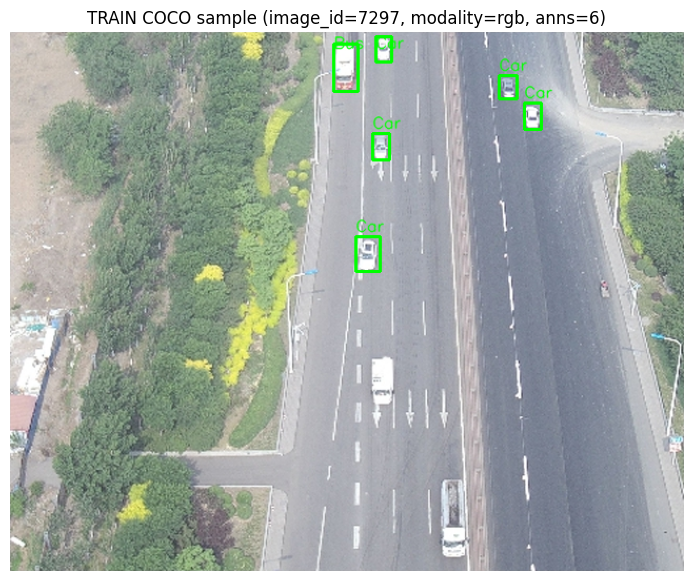

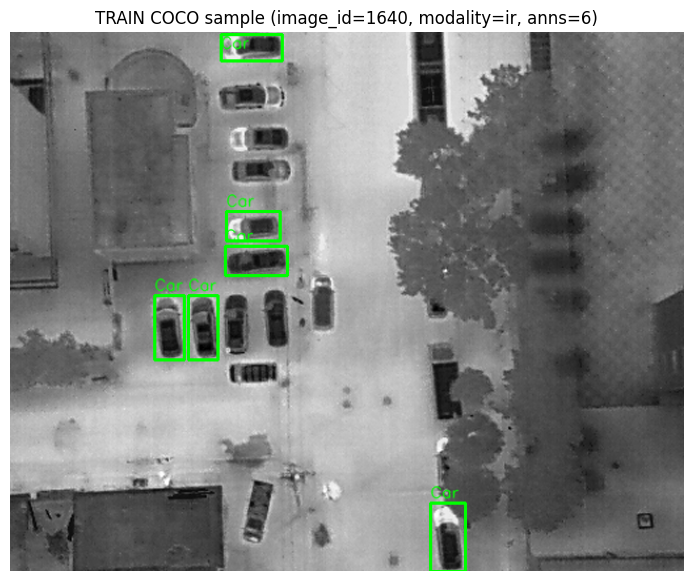

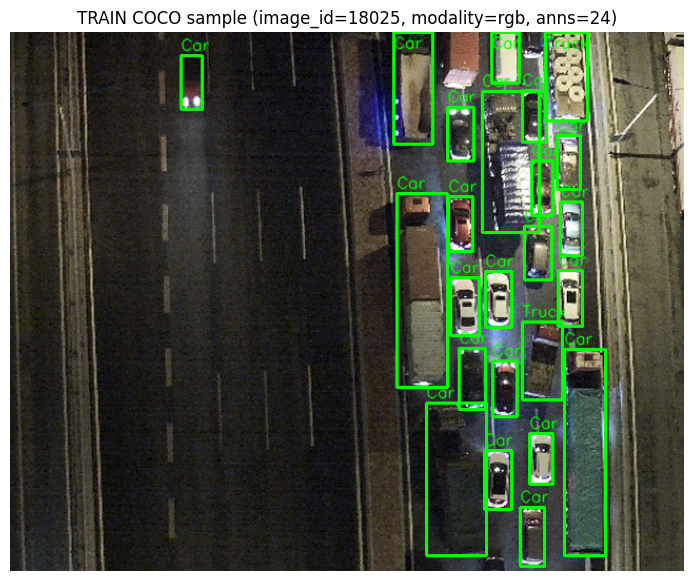

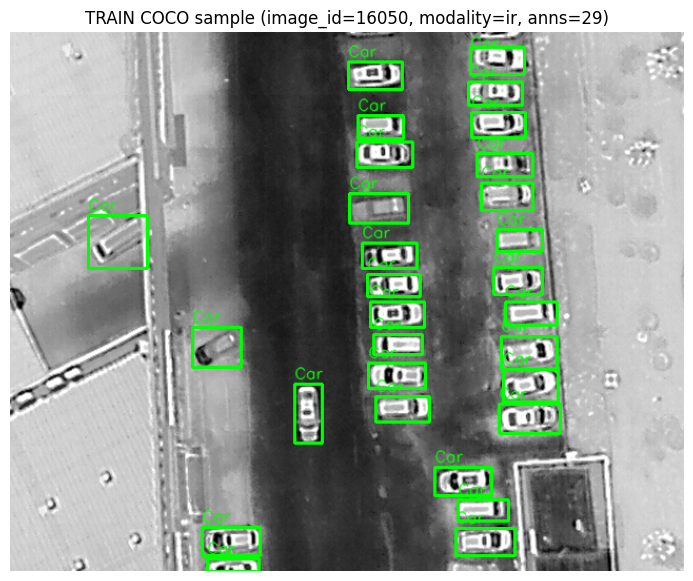

In [14]:
# ============================================================
# Cell 7: Validate COCO Output + Visual Sanity Check
# ============================================================

VALIDATE_SPLIT = "train"

COCO_JSON_PATH = COCO_OUTPUT_DIR / f"dronevehicle_{VALIDATE_SPLIT}_coco.json"

assert COCO_JSON_PATH.exists(), f"COCO JSON not found: {COCO_JSON_PATH}"
assert VALIDATE_SPLIT in DATASET_STRUCTURE, f"Unknown split: {VALIDATE_SPLIT}"

print(f"Loading COCO annotations from:\n{COCO_JSON_PATH}\n")

coco = COCO(str(COCO_JSON_PATH))

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def parse_coco_export_file_name(file_name: str):
    """
    Expected format from Cell 6:
        <split>_<modality>_<original_image_name>
    Example:
        train_rgb_00001.jpg
        val_ir_01234.JPG
    """
    prefix = f"{VALIDATE_SPLIT}_"
    assert file_name.startswith(prefix), f"Unexpected file_name prefix: {file_name}"

    remainder = file_name[len(prefix):]
    modality, original_name = remainder.split("_", 1)

    if modality not in {"rgb", "ir"}:
        raise ValueError(f"Unexpected modality in COCO file_name: {file_name}")

    return modality, original_name

def crop_white_border(img_bgr):
    if not DRONEVEHICLE_BORDER_POLICY["remove_white_border"]:
        return img_bgr

    left = DRONEVEHICLE_BORDER_POLICY["border_pixels"]["left"]
    right = DRONEVEHICLE_BORDER_POLICY["border_pixels"]["right"]
    top = DRONEVEHICLE_BORDER_POLICY["border_pixels"]["top"]
    bottom = DRONEVEHICLE_BORDER_POLICY["border_pixels"]["bottom"]

    h, w = img_bgr.shape[:2]
    cropped = img_bgr[top:h-bottom, left:w-right]

    expected_w = DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["width"]
    expected_h = DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["height"]

    assert cropped.shape[1] == expected_w, (
        f"Cropped width mismatch. Expected {expected_w}, got {cropped.shape[1]}"
    )
    assert cropped.shape[0] == expected_h, (
        f"Cropped height mismatch. Expected {expected_h}, got {cropped.shape[0]}"
    )

    return cropped

# ------------------------------------------------------------
# Verify categories against canonical metadata
# ------------------------------------------------------------
cats = sorted(coco.loadCats(coco.getCatIds()), key=lambda c: c["id"])
exported_cat_ids = [c["id"] for c in cats]
exported_cat_names = [c["name"] for c in cats]

assert exported_cat_ids == list(range(1, NUM_CLASSES + 1)), (
    f"Exported category ids mismatch.\n"
    f"Expected: {list(range(1, NUM_CLASSES + 1))}\n"
    f"Got     : {exported_cat_ids}"
)

assert exported_cat_names == PHASE3_CLASS_NAMES, (
    f"Exported category names mismatch.\n"
    f"Expected: {PHASE3_CLASS_NAMES}\n"
    f"Got     : {exported_cat_names}"
)

print("=== COCO Categories (Validated) ===")
for c in cats:
    print(f"id={c['id']} | name={c['name']}")
print("===================================\n")

# ------------------------------------------------------------
# Dataset statistics
# ------------------------------------------------------------
num_images = len(coco.getImgIds())
num_annotations = len(coco.getAnnIds())

print("=== Dataset Statistics ===")
print(f"Images     : {num_images}")
print(f"Annotations: {num_annotations}")
print("==========================\n")

# ------------------------------------------------------------
# Cross-check against conversion summary
# ------------------------------------------------------------
if VALIDATE_SPLIT in COCO_EXPORT_SUMMARY:
    expected_images = COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["images_total"]
    expected_annotations = COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["annotations_total"]

    assert num_images == expected_images, (
        f"Image count mismatch for split '{VALIDATE_SPLIT}'. "
        f"Expected {expected_images}, got {num_images}"
    )
    assert num_annotations == expected_annotations, (
        f"Annotation count mismatch for split '{VALIDATE_SPLIT}'. "
        f"Expected {expected_annotations}, got {num_annotations}"
    )

# ------------------------------------------------------------
# Per-class annotation counts
# ------------------------------------------------------------
print("=== Per-Class Annotation Counts ===")
for c in cats:
    cat_id = c["id"]
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    print(f"{c['name']:<8}: {len(ann_ids)}")
print("==================================\n")

# ------------------------------------------------------------
# Modality counts
# ------------------------------------------------------------
all_imgs = coco.loadImgs(coco.getImgIds())
rgb_count = sum(1 for img in all_imgs if img.get("modality") == "rgb")
ir_count  = sum(1 for img in all_imgs if img.get("modality") == "ir")

print("=== Modality Counts ===")
print(f"RGB images: {rgb_count}")
print(f"IR images : {ir_count}")
print("=======================\n")

if VALIDATE_SPLIT in COCO_EXPORT_SUMMARY:
    assert rgb_count == COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["rgb_images_total"], (
        f"RGB image count mismatch. Expected {COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]['rgb_images_total']}, got {rgb_count}"
    )
    assert ir_count == COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["ir_images_total"], (
        f"IR image count mismatch. Expected {COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]['ir_images_total']}, got {ir_count}"
    )

# ------------------------------------------------------------
# Strong annotation sanity checks
# ------------------------------------------------------------
all_img_ids = set(coco.getImgIds())
all_anns = coco.loadAnns(coco.getAnnIds())

invalid_category_count = 0
invalid_image_ref_count = 0
invalid_box_count = 0
invalid_box_bounds_count = 0

img_id_to_info = {img["id"]: img for img in all_imgs}

for ann in all_anns:
    if ann["category_id"] not in PHASE3_CLASSES:
        invalid_category_count += 1

    if ann["image_id"] not in all_img_ids:
        invalid_image_ref_count += 1
        continue

    x, y, w, h = ann["bbox"]
    if w <= 0 or h <= 0:
        invalid_box_count += 1
        continue

    img_info = img_id_to_info[ann["image_id"]]
    img_w = img_info["width"]
    img_h = img_info["height"]

    if x < 0 or y < 0 or x + w > img_w + 1e-6 or y + h > img_h + 1e-6:
        invalid_box_bounds_count += 1

assert invalid_category_count == 0, f"Found {invalid_category_count} annotations with invalid category_id"
assert invalid_image_ref_count == 0, f"Found {invalid_image_ref_count} annotations with invalid image_id"
assert invalid_box_count == 0, f"Found {invalid_box_count} annotations with non-positive boxes"
assert invalid_box_bounds_count == 0, f"Found {invalid_box_bounds_count} annotations outside image bounds"

print("=== Annotation Integrity Checks Passed ===")
print("All category_ids are valid")
print("All image references are valid")
print("All boxes have positive width/height")
print("All boxes lie within cropped image bounds")
print("==========================================\n")

# ------------------------------------------------------------
# Visualize reproducible random samples
# IMPORTANT:
# - COCO boxes are in cropped-image coordinates
# - so we must load the original source image and crop the border first
# ------------------------------------------------------------
NUM_SAMPLES = 4
rng = random.Random(SEED)

sample_img_ids = rng.sample(coco.getImgIds(), min(NUM_SAMPLES, len(coco.getImgIds())))

split_info = DATASET_STRUCTURE[VALIDATE_SPLIT]
rgb_images_dir = split_info["rgb_images_dir"]
ir_images_dir  = split_info["ir_images_dir"]

for img_id in sample_img_ids:
    img_info = coco.loadImgs(img_id)[0]
    ann_ids = coco.getAnnIds(imgIds=[img_id])
    anns = coco.loadAnns(ann_ids)

    modality = img_info.get("modality")
    coco_file_name = img_info["file_name"]
    parsed_modality, original_image_name = parse_coco_export_file_name(coco_file_name)

    assert modality == parsed_modality, (
        f"Modality mismatch for image_id={img_id}: "
        f"img_info modality={modality}, parsed modality={parsed_modality}"
    )

    if modality == "rgb":
        source_img_path = rgb_images_dir / original_image_name
    elif modality == "ir":
        source_img_path = ir_images_dir / original_image_name
    else:
        raise ValueError(f"Unexpected modality: {modality}")

    assert source_img_path.exists(), f"Source image not found: {source_img_path}"

    img = cv2.imread(str(source_img_path), cv2.IMREAD_COLOR)
    assert img is not None, f"Failed to load image: {source_img_path}"

    img = crop_white_border(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for ann in anns:
        x, y, w, h = ann["bbox"]
        x1, y1, x2, y2 = map(int, [x, y, x + w, y + h])

        cls_name = class_id_to_name(ann["category_id"])

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )
        cv2.putText(
            img,
            cls_name,
            (x1, max(15, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA
        )

    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{VALIDATE_SPLIT.upper()} COCO sample "
        f"(image_id={img_id}, modality={modality}, anns={len(anns)})"
    )
    plt.show()

In [15]:
# ============================================================
# Cell 8: Create or Reuse COCO-Compatible Dataset Shim for RF-DETR
# Crop + rename DroneVehicle RGB/IR images to match COCO export
# ============================================================

import shutil

print("\n=== Create / Reuse RF-DETR COCO dataset shim ===\n")

# ---- COCO annotation source dir from Cell 6 ----
COCO_ANN_SRC = COCO_OUTPUT_DIR

# ---- Dedicated shim root so old shim is preserved ----
SHIM_ROOT = RFDETR_ROOT / "infrared-data-shim"

# ---- RF-DETR expected COCO-style structure ----
COCO_TRAIN_IMG = SHIM_ROOT / "train2017"
COCO_VAL_IMG = SHIM_ROOT / "val2017"
COCO_TEST_IMG = SHIM_ROOT / "test2017"
COCO_ANN_DIR = SHIM_ROOT / "annotations"

COCO_TRAIN_ANN = COCO_ANN_DIR / "instances_train2017.json"
COCO_VAL_ANN = COCO_ANN_DIR / "instances_val2017.json"
COCO_TEST_ANN = COCO_ANN_DIR / "instances_test2017.json"

# ---- Create directories ----
for d in [COCO_TRAIN_IMG, COCO_VAL_IMG, COCO_TEST_IMG, COCO_ANN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- Source annotation JSONs ----
TRAIN_SRC_ANN = COCO_ANN_SRC / "dronevehicle_train_coco.json"
VAL_SRC_ANN = COCO_ANN_SRC / "dronevehicle_val_coco.json"
TEST_SRC_ANN = COCO_ANN_SRC / "dronevehicle_test_coco.json"

assert TRAIN_SRC_ANN.exists(), f"Missing train COCO json: {TRAIN_SRC_ANN}"
assert VAL_SRC_ANN.exists(), f"Missing val COCO json: {VAL_SRC_ANN}"
assert TEST_SRC_ANN.exists(), f"Missing test COCO json: {TEST_SRC_ANN}"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def crop_white_border(img_bgr):
    if not DRONEVEHICLE_BORDER_POLICY["remove_white_border"]:
        return img_bgr

    left = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["left"])
    right = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["right"])
    top = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["top"])
    bottom = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["bottom"])

    h, w = img_bgr.shape[:2]
    cropped = img_bgr[top:h-bottom, left:w-right]

    expected_w = int(DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["width"])
    expected_h = int(DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["height"])

    assert cropped.shape[1] == expected_w, (
        f"Cropped width mismatch. Expected {expected_w}, got {cropped.shape[1]}"
    )
    assert cropped.shape[0] == expected_h, (
        f"Cropped height mismatch. Expected {expected_h}, got {cropped.shape[0]}"
    )

    return cropped


def resolve_original_image_path(split_name: str, modality: str, original_image_name: str) -> Path:
    split_info = DATASET_STRUCTURE[split_name]

    if modality == "rgb":
        candidate = split_info["rgb_images_dir"] / original_image_name
    elif modality == "ir":
        candidate = split_info["ir_images_dir"] / original_image_name
    else:
        raise ValueError(f"Unexpected modality: {modality}")

    if candidate.exists():
        return candidate

    stem = Path(original_image_name).stem
    ext_candidates = [".jpg", ".JPG", ".jpeg", ".JPEG"]

    base_dir = split_info["rgb_images_dir"] if modality == "rgb" else split_info["ir_images_dir"]

    for ext in ext_candidates:
        p = base_dir / f"{stem}{ext}"
        if p.exists():
            return p

    raise FileNotFoundError(
        f"Could not resolve original image for split={split_name}, modality={modality}, "
        f"original_image_name={original_image_name}"
    )


def list_image_files(folder: Path):
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg"}]
    )


def load_coco_json(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)


def validate_annotation_json(src_json: Path, dst_json: Path, split_name: str):
    assert dst_json.exists(), f"{split_name} shim annotation json missing: {dst_json}"

    src_coco = load_coco_json(src_json)
    dst_coco = load_coco_json(dst_json)

    src_categories = sorted(src_coco["categories"], key=lambda c: c["id"])
    dst_categories = sorted(dst_coco["categories"], key=lambda c: c["id"])

    src_cat_ids = [c["id"] for c in src_categories]
    dst_cat_ids = [c["id"] for c in dst_categories]

    src_cat_names = [c["name"] for c in src_categories]
    dst_cat_names = [c["name"] for c in dst_categories]

    assert dst_cat_ids == list(range(1, NUM_CLASSES + 1)), (
        f"{split_name} annotation ids mismatch: {dst_cat_ids}"
    )
    assert dst_cat_names == PHASE3_CLASS_NAMES, (
        f"{split_name} annotation names mismatch.\n"
        f"Expected: {PHASE3_CLASS_NAMES}\n"
        f"Got     : {dst_cat_names}"
    )

    assert src_cat_ids == dst_cat_ids, (
        f"{split_name} source/destination category id mismatch.\n"
        f"Source: {src_cat_ids}\n"
        f"Dest  : {dst_cat_ids}"
    )
    assert src_cat_names == dst_cat_names, (
        f"{split_name} source/destination category name mismatch.\n"
        f"Source: {src_cat_names}\n"
        f"Dest  : {dst_cat_names}"
    )

    assert len(src_coco["images"]) == len(dst_coco["images"]), (
        f"{split_name} source/destination image count mismatch in JSON.\n"
        f"Source: {len(src_coco['images'])}\n"
        f"Dest  : {len(dst_coco['images'])}"
    )
    assert len(src_coco["annotations"]) == len(dst_coco["annotations"]), (
        f"{split_name} source/destination annotation count mismatch in JSON.\n"
        f"Source: {len(src_coco['annotations'])}\n"
        f"Dest  : {len(dst_coco['annotations'])}"
    )


def is_split_shim_ready(src_ann_json: Path, dst_img_dir: Path, dst_ann_json: Path, split_name: str):
    """
    Returns True if the split shim already looks valid and can be reused.
    """
    if not src_ann_json.exists():
        return False
    if not dst_img_dir.exists():
        return False
    if not dst_ann_json.exists():
        return False

    src_coco = load_coco_json(src_ann_json)
    expected_count = len(src_coco["images"])
    existing_images = list_image_files(dst_img_dir)

    if expected_count == 0:
        return False
    if len(existing_images) != expected_count:
        return False

    try:
        validate_annotation_json(src_ann_json, dst_ann_json, split_name)
    except Exception as e:
        print(f"[WARN] Existing {split_name} shim annotation validation failed: {e}")
        return False

    return True


def clear_split_dir(dst_img_dir: Path):
    existing_images = list_image_files(dst_img_dir)
    for p in existing_images:
        p.unlink()


def prepare_split_images_from_coco(src_ann_json: Path, dst_img_dir: Path, split_name: str):
    """
    Read COCO JSON from Cell 6 and physically materialize cropped images into the
    RF-DETR COCO-style image directory using the exact COCO file_name.
    """
    coco_json = load_coco_json(src_ann_json)
    images = coco_json["images"]
    expected_count = len(images)
    existing_images = list_image_files(dst_img_dir)

    if len(existing_images) == expected_count and expected_count > 0:
        print(f"[SKIP] {split_name} images already prepared ({expected_count} files)")
        return

    if len(existing_images) > 0:
        print(f"[WARN] {split_name} destination has stale/partial contents; refreshing it")
        clear_split_dir(dst_img_dir)

    print(f"[PREP] {split_name}: materializing {expected_count} cropped COCO images")

    for img_info in tqdm(images, desc=f"Preparing {split_name} images"):
        coco_file_name = img_info["file_name"]
        modality = img_info.get("modality")
        original_image_name = img_info.get("original_file_name")

        assert modality in {"rgb", "ir"}, (
            f"Missing/invalid modality for COCO image entry: {img_info}"
        )
        assert original_image_name is not None, (
            f"Missing original_file_name in COCO image entry: {img_info}"
        )

        src_img_path = resolve_original_image_path(
            split_name=split_name,
            modality=modality,
            original_image_name=original_image_name,
        )
        dst_img_path = dst_img_dir / coco_file_name

        img = cv2.imread(str(src_img_path), cv2.IMREAD_COLOR)
        assert img is not None, f"Failed to load image: {src_img_path}"

        img = crop_white_border(img)

        expected_w = int(img_info["width"])
        expected_h = int(img_info["height"])

        assert img.shape[1] == expected_w, (
            f"{split_name} width mismatch for {coco_file_name}: "
            f"expected {expected_w}, got {img.shape[1]}"
        )
        assert img.shape[0] == expected_h, (
            f"{split_name} height mismatch for {coco_file_name}: "
            f"expected {expected_h}, got {img.shape[0]}"
        )

        ok = cv2.imwrite(str(dst_img_path), img)
        assert ok, f"Failed to save cropped image: {dst_img_path}"

    final_count = len(list_image_files(dst_img_dir))
    assert final_count == expected_count, (
        f"{split_name} image preparation failed: expected {expected_count}, got {final_count}"
    )


def copy_annotation_if_needed(src: Path, dst: Path, split_name: str):
    """
    Copy annotation JSON only if missing or if source/destination differ in key counts.
    """
    should_copy = True

    if dst.exists():
        try:
            src_coco = load_coco_json(src)
            dst_coco = load_coco_json(dst)

            same_images = len(src_coco["images"]) == len(dst_coco["images"])
            same_anns = len(src_coco["annotations"]) == len(dst_coco["annotations"])
            same_cats = src_coco["categories"] == dst_coco["categories"]

            if same_images and same_anns and same_cats:
                should_copy = False
        except Exception:
            should_copy = True

    if should_copy:
        shutil.copy2(src, dst)
        print(f"[COPY] {split_name} annotation -> {dst.name}")
    else:
        print(f"[SKIP] {split_name} annotation already valid -> {dst.name}")

    validate_annotation_json(src, dst, split_name)


def ensure_split_shim(src_ann_json: Path, dst_img_dir: Path, dst_ann_json: Path, split_name: str):
    """
    Reuse a valid split shim if present; otherwise rebuild it.
    """
    if is_split_shim_ready(src_ann_json, dst_img_dir, dst_ann_json, split_name):
        print(f"[REUSE] {split_name} shim already valid")
        return

    print(f"[BUILD] {split_name} shim needs creation or refresh")
    prepare_split_images_from_coco(src_ann_json, dst_img_dir, split_name)
    copy_annotation_if_needed(src_ann_json, dst_ann_json, split_name)

    assert is_split_shim_ready(src_ann_json, dst_img_dir, dst_ann_json, split_name), (
        f"{split_name} shim failed final validation after rebuild"
    )


# ------------------------------------------------------------
# Ensure train / val / test shim exists and is valid
# ------------------------------------------------------------
ensure_split_shim(TRAIN_SRC_ANN, COCO_TRAIN_IMG, COCO_TRAIN_ANN, "train")
ensure_split_shim(VAL_SRC_ANN, COCO_VAL_IMG, COCO_VAL_ANN, "val")
ensure_split_shim(TEST_SRC_ANN, COCO_TEST_IMG, COCO_TEST_ANN, "test")


# ------------------------------------------------------------
# Final validation summary
# ------------------------------------------------------------
train_dst_count = len(list_image_files(COCO_TRAIN_IMG))
val_dst_count = len(list_image_files(COCO_VAL_IMG))
test_dst_count = len(list_image_files(COCO_TEST_IMG))

print("\n=== COCO shim ready ===")
print(f"Shim root     : {SHIM_ROOT}")
print(f"Train images  : {COCO_TRAIN_IMG} ({train_dst_count} files)")
print(f"Val images    : {COCO_VAL_IMG} ({val_dst_count} files)")
print(f"Test images   : {COCO_TEST_IMG} ({test_dst_count} files)")
print(f"Annotations   : {COCO_ANN_DIR}")
print(f"Train ann     : {COCO_TRAIN_ANN.name}")
print(f"Val ann       : {COCO_VAL_ANN.name}")
print(f"Test ann      : {COCO_TEST_ANN.name}")
print("Canonical categories verified in shim annotation JSONs.")
print("Shim contains both RGB and infrared samples as independent COCO images.")


=== Create / Reuse RF-DETR COCO dataset shim ===

[REUSE] train shim already valid
[REUSE] val shim already valid
[REUSE] test shim already valid

=== COCO shim ready ===
Shim root     : E:\projects\object-identification-uav-camera\phase-3\rfdetr\infrared-data-shim
Train images  : E:\projects\object-identification-uav-camera\phase-3\rfdetr\infrared-data-shim\train2017 (35980 files)
Val images    : E:\projects\object-identification-uav-camera\phase-3\rfdetr\infrared-data-shim\val2017 (2938 files)
Test images   : E:\projects\object-identification-uav-camera\phase-3\rfdetr\infrared-data-shim\test2017 (17960 files)
Annotations   : E:\projects\object-identification-uav-camera\phase-3\rfdetr\infrared-data-shim\annotations
Train ann     : instances_train2017.json
Val ann       : instances_val2017.json
Test ann      : instances_test2017.json
Canonical categories verified in shim annotation JSONs.
Shim contains both RGB and infrared samples as independent COCO images.


In [16]:
# ============================================================
# Cell 9: Forward-Only RF-DETR Sanity Check
# NO training, NO backward pass
#
# Purpose:
# - Validate dataset + model compatibility
# - Catch class/count/path mismatches before training
# - Debug tensor / shape issues early
# ============================================================

import torch
from types import SimpleNamespace
from rfdetr import RFDETRNano
from rfdetr.datasets.coco import build as build_coco

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nRunning forward-only sanity check on device: {device}\n")

# ---- Verify shim paths exist ----
assert SHIM_ROOT.exists(), f"Missing shim root: {SHIM_ROOT}"
assert COCO_TRAIN_IMG.exists(), f"Missing COCO train image dir: {COCO_TRAIN_IMG}"
assert COCO_VAL_IMG.exists(), f"Missing COCO val image dir: {COCO_VAL_IMG}"
assert COCO_TRAIN_ANN.exists(), f"Missing COCO train annotation json: {COCO_TRAIN_ANN}"
assert COCO_VAL_ANN.exists(), f"Missing COCO val annotation json: {COCO_VAL_ANN}"

print("Using COCO shim root:", SHIM_ROOT)
print("Train images     :", COCO_TRAIN_IMG)
print("Val images       :", COCO_VAL_IMG)
print("Train ann        :", COCO_TRAIN_ANN)
print("Val ann          :", COCO_VAL_ANN)

# ---- Initialize RF-DETR Nano with canonical class count ----
model = RFDETRNano(num_classes=NUM_CLASSES)

# Access underlying torch model
torch_model = model.model.model
torch_model.to(device)
torch_model.eval()

# ---- Minimal args object required by RF-DETR COCO dataset builder ----
args = SimpleNamespace(
    dataset_file="coco",
    coco_path=str(SHIM_ROOT),
    square_resize_div_64=True,
    multi_scale=False,
    expanded_scales=False,
    do_random_resize_via_padding=False,
    patch_size=16,
    num_windows=2,
)

# ---- Build training dataset from the new infrared shim ----
dataset = build_coco(
    image_set="train",
    args=args,
    resolution=TARGET_IMAGE_SIZE,
)

print(f"\nDataset length: {len(dataset)}")
assert len(dataset) > 0, "Dataset is empty"

# Optional cross-check against export summary / shim size
if "train" in COCO_EXPORT_SUMMARY:
    expected_len = COCO_EXPORT_SUMMARY["train"]["images_total"]
    print(f"Expected train images from COCO export: {expected_len}")
    assert len(dataset) == expected_len, (
        f"Dataset length mismatch: expected {expected_len}, got {len(dataset)}"
    )

# ---- Fetch one sample ----
samples, targets = dataset[0]

print("\n=== Sample Inspection ===")
print(f"Sample tensor shape: {tuple(samples.shape)}")
print(f"Target keys        : {list(targets.keys())}")

assert "boxes" in targets, "Missing 'boxes' in targets"
assert "labels" in targets, "Missing 'labels' in targets"

num_target_boxes = len(targets["boxes"])
unique_labels = sorted(set(targets["labels"].cpu().numpy().tolist()))

print(f"Number of boxes    : {num_target_boxes}")
print(f"Unique label ids   : {unique_labels}")

assert num_target_boxes > 0, "Sample has zero target boxes"

# ---- Validate target labels ----
for label_id in unique_labels:
    assert 1 <= int(label_id) <= NUM_CLASSES, (
        f"Found out-of-range label_id={label_id}; expected within 1..{NUM_CLASSES}"
    )

# ---- Validate target boxes ----
boxes = targets["boxes"]
assert boxes.ndim == 2 and boxes.shape[1] == 4, (
    f"Expected target boxes shape [N, 4], got {tuple(boxes.shape)}"
)

# Useful quick stats
box_min = boxes.min().item()
box_max = boxes.max().item()
print(f"Box value range    : min={box_min:.4f}, max={box_max:.4f}")

# Batchify
samples = samples.unsqueeze(0).to(device)
targets = [{k: v.to(device) for k, v in targets.items()}]

# ---- Forward pass ONLY ----
with torch.no_grad():
    outputs = torch_model(samples, targets)

print("\nForward pass successful")
print("Output keys:", list(outputs.keys()))

assert "pred_logits" in outputs, "Missing 'pred_logits' in model outputs"
assert "pred_boxes" in outputs, "Missing 'pred_boxes' in model outputs"

pred_logits = outputs["pred_logits"]
pred_boxes = outputs["pred_boxes"]

print("\n=== Output Shape Inspection ===")
print(f"pred_logits shape: {tuple(pred_logits.shape)}")
print(f"pred_boxes shape : {tuple(pred_boxes.shape)}")

# Basic shape checks
assert pred_logits.ndim == 3, f"Expected pred_logits ndim=3, got {pred_logits.ndim}"
assert pred_boxes.ndim == 3, f"Expected pred_boxes ndim=3, got {pred_boxes.ndim}"
assert pred_boxes.shape[-1] == 4, (
    f"Expected pred_boxes last dim = 4, got {pred_boxes.shape[-1]}"
)

print("\n=== Class Mapping Check ===")
print(f"Canonical num_classes : {NUM_CLASSES}")
print(f"Canonical class names : {PHASE3_CLASS_NAMES}")

print("Forward-only sanity check passed.")


Running forward-only sanity check on device: cuda

Using COCO shim root: E:\projects\object-identification-uav-camera\phase-3\rfdetr\infrared-data-shim
Train images     : E:\projects\object-identification-uav-camera\phase-3\rfdetr\infrared-data-shim\train2017
Val images       : E:\projects\object-identification-uav-camera\phase-3\rfdetr\infrared-data-shim\val2017
Train ann        : E:\projects\object-identification-uav-camera\phase-3\rfdetr\infrared-data-shim\annotations\instances_train2017.json
Val ann          : E:\projects\object-identification-uav-camera\phase-3\rfdetr\infrared-data-shim\annotations\instances_val2017.json
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
loadi